<a href="https://colab.research.google.com/github/WVF-1/Utopia-25-Cellular-Automata-Experiment/blob/main/Utopia_25_Simulation_Micro_Layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐀 Utopia 25 — Agent-Based Simulation

> *"The most beautiful animal in the world" — John B. Calhoun, 1962*

This notebook implements an agent-based model of Calhoun's **Universe 25** experiment (1968–1973), in which a colony of mice was given unlimited food, water, and nesting space inside a 2.7 m² enclosure. Despite ideal material conditions, the population collapsed — passing through a **Behavioural Sink** phase characterised by withdrawal, reproductive failure, and social fragmentation.

---

### Simulation Architecture

| Phase | Content |
|---|---|
| 1 | Setup & Imports |
| 2 | Hex Grid Engine |
| 3 | Rat Agent Definition |
| 4 | Environment Configurations (A–D) |
| 5 | Simulation Engine |
| 6 | Visualisation |
| 7 | Metrics & Analysis |
| 8 | Run Experiments |

### Withdrawal Pressure Formula
$$W = \alpha D + \beta S + \gamma R + \delta I$$
where $D$ = local density, $S$ = stress, $R$ = reproductive frustration, $I$ = normalised interaction count.

---

## Phase 1 — Setup & Imports

In [28]:
# ── Install / upgrade anything not present in Colab ──────────────────────────
# matplotlib, numpy, pandas, scipy are already available; nothing extra needed.
# If you want seaborn heatmaps: uncomment the line below.
# !pip install -q seaborn

import math
import random
import copy
import itertools
from dataclasses import dataclass, field
from enum import Enum, auto
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.collections import PatchCollection
from matplotlib.patches import RegularPolygon
import matplotlib.gridspec as gridspec

random.seed(42)
np.random.seed(42)

print(f"NumPy  {np.__version__}")
print(f"Pandas {pd.__version__}")
print(f"Matplotlib {matplotlib.__version__}")
print("\n✅ All imports successful.")

NumPy  2.0.2
Pandas 2.2.2
Matplotlib 3.10.0

✅ All imports successful.


In [29]:
# ── Colour palette (cinema-inspired, Utopia 25 mood board) ───────────────────

PALETTE = {
    # Background / grid
    "bg":          "#0d0d0d",
    "grid_empty":  "#1a1a2e",
    "grid_line":   "#2a2a4a",

    # Agent states
    "active":      "#e8c547",   # warm gold   — healthy, social
    "withdrawn":   "#4a90d9",   # steel blue  — withdrawn / beautiful one
    "dead":        "#3a3a3a",   # charcoal    — deceased

    # Stress heatmap
    "stress_lo":   "#1a472a",
    "stress_hi":   "#c0392b",

    # Accent / annotation
    "accent":      "#e74c3c",
    "text":        "#f0ebe3",
    "muted":       "#888888",
}

# Matplotlib style overrides
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor":   PALETTE["bg"],
    "axes.edgecolor":   PALETTE["muted"],
    "axes.labelcolor":  PALETTE["text"],
    "xtick.color":      PALETTE["muted"],
    "ytick.color":      PALETTE["muted"],
    "text.color":       PALETTE["text"],
    "grid.color":       PALETTE["grid_line"],
    "grid.alpha":       0.4,
    "legend.facecolor": "#1a1a2e",
    "legend.edgecolor": PALETTE["muted"],
    "font.family":      "monospace",
})

# ── Global simulation constants ───────────────────────────────────────────────

GRID_ROWS    = 10
GRID_COLS    = 10
MAX_TICKS    = 3000        # maximum simulation time-steps
MAX_AGENTS   = 2200        # hard population ceiling (physical space limit)
# Ticks correspond to roughly half a day
# Agents is capped at the observed population maximum from the experiment

# -----------------------------------------------------------------------
# Experiment Logic
# -----------------------------------------------------------------------
#
# In Calhoun's experiment, Utopia 25 ran for roughly four years.
# 1,500 days to simulate enables a handful of extra days for rigor.
# The maximum observed population before collapse was 2,200 rats.
# For this reason, the maximum agents in this simulation is the same.
#
# -----------------------------------------------------------------------

# Withdrawal pressure weights  W = α·D + β·S + γ·R + δ·I
ALPHA = 0.15   # density weight
BETA  = 0.30   # stress weight
GAMMA = 0.45   # reproductive-frustration weight
DELTA = 0.10   # interaction count weight

# State-transition thresholds
WITHDRAW_THRESH      = 0.80    # W above this  → Active becomes Withdrawn
# RECOVER_THRESH is removed for irreversible withdrawal
DEATH_STRESS_THRESH  = 0.90    # stress above this → mortality risk
# Set to 0.9, as the maximum infant mortality rate from the real study was
# observed at 0.9 at its worst, so that would be maximum stress.

# Stress dynamics
STRESS_INTERACTION_INC = 0.015   # per unwanted interaction
STRESS_ISOLATION_DEC   = 0.015  # per tick without interaction
STRESS_DECAY           = 0.01  # passive background decay per tick
INTERACTION_THRESHOLD  = 3      # interactions/tick beyond which stress rises

# Reproduction
BASE_REPRO_PROB       = 0.20
REPRO_MIN_AGE         = 10
REPRO_MAX_AGE         = 200
REPRO_STRESS_PENALTY  = 0.45    # scalar — reduces repro prob under stress

# Lifespan / ageing
MAX_AGE               = 300
SENESCENCE_START      = 220    # age at which mortality risk begins climbing

# Additional Agent Variables (now used in RatAgent class)
# inherited_stress:               float = 0.0  # Initialized in _new_agent for children
# social_resilience:              float = 1.0  # Initialized in _new_agent for children
# reproductive_confidence:        float = 1.0  # Initialized in _new_agent for children

# New constants for upgrades:
WITHDRAWN_NEIGHBOR_INFLUENCE = 0.015 # Social contagion influence
REPRO_FAILURE_DECAY = 0.10          # Reproduction modifier decay factor
INHERITED_STRESS_FACTOR = 0.35      # Factor for inherited stress
SOCIAL_RESILIENCE_DECAY = 0.97      # Factor for social resilience decay
JUVENILE_AGE_MAX = 15               # Max age for juvenile stage
JUVENILE_STRESS_DEATH_PROB = 0.03   # Probability of juvenile death due to stress

# New constant for phase-gated collapse mechanics
SATURATION_THRESHOLD = 500          # Population threshold to activate full collapse mechanics

# New constants for individual resilience and withdrawal dynamics
INDIVIDUAL_RESILIENCE_RANGE = (0.8, 1.2) # Min and max for random resilience factor
WITHDRAWAL_PERSISTENCE_TICKS = 15    # Consecutive ticks W > thresh before withdrawal
CHRONIC_STRESS_FLOOR_WITHDRAWN = 0.25 # Minimum stress level for withdrawn agents
RECOVERY_PROBABILITY = 0.002       # Small chance for withdrawn agents to recover

# Reproduction modifier based on withdrawal duration
REPRO_MODIFIER_WITHDRAWN_DURATIONS = {
    (0, 25):  0.8,
    (26, 75): 0.5,
    (76, 150): 0.2,
    (151, math.inf): 0.0,
}

print("✅ Constants defined.")

✅ Constants defined.


---
## Phase 2 — Hex Grid Engine

In [30]:
# ── Odd-r offset coordinate system (pointy-top hexagons) ─────────────────────
#
#  Even row neighbours:  (r, c±1), (r-1, c-1), (r-1, c), (r+1, c-1), (r+1, c)
#  Odd  row neighbours:  (r, c±1), (r-1,  c ), (r-1, c+1), (r+1,  c), (r+1, c+1)

EVEN_ROW_DELTAS = [( 0, +1), ( 0, -1), (-1, -1), (-1,  0), (+1, -1), (+1,  0)]
ODD_ROW_DELTAS  = [( 0, +1), ( 0, -1), (-1,  0), (-1, +1), (+1,  0), (+1, +1)]


class HexGrid:
    """
    Odd-r offset hex grid.

    Each cell is identified by (row, col).  The grid stores:
        _occupants : Dict[(r,c), List[agent_id]]
    """

    def __init__(self, rows: int, cols: int):
        self.rows = rows
        self.cols = cols
        # occupant list per cell
        self._occupants: Dict[Tuple[int,int], List[int]] = {
            (r, c): [] for r in range(rows) for c in range(cols)
        }
        # adjacency cache
        self._neighbour_cache: Dict[Tuple[int,int], List[Tuple[int,int]]] = {}

    # ── Neighbours ──────────────────────────────────────────────────────────

    def neighbours(self, r: int, c: int) -> List[Tuple[int,int]]:
        """Return valid in-bounds neighbour cells for (r, c)."""
        key = (r, c)
        if key not in self._neighbour_cache:
            deltas = ODD_ROW_DELTAS if (r % 2 == 1) else EVEN_ROW_DELTAS
            nbrs = []
            for dr, dc in deltas:
                nr, nc = r + dr, c + dc
                if 0 <= nr < self.rows and 0 <= nc < self.cols:
                    nbrs.append((nr, nc))
            self._neighbour_cache[key] = nbrs
        return self._neighbour_cache[key]

    # ── Occupancy ────────────────────────────────────────────────────────────

    def place(self, agent_id: int, r: int, c: int):
        """Place an agent at (r, c)."""
        self._occupants[(r, c)].append(agent_id)

    def remove(self, agent_id: int, r: int, c: int):
        """Remove an agent from (r, c)."""
        if agent_id in self._occupants[(r, c)]:
            self._occupants[(r, c)].remove(agent_id)

    def move(self, agent_id: int, from_cell: Tuple[int,int], to_cell: Tuple[int,int]):
        self.remove(agent_id, *from_cell)
        self.place(agent_id, *to_cell)

    def occupants(self, r: int, c: int) -> List[int]:
        return list(self._occupants[(r, c)])

    def cell_count(self, r: int, c: int) -> int:
        return len(self._occupants[(r, c)])

    def total_agents(self) -> int:
        return sum(len(v) for v in self._occupants.values())

    # ── Local density (fraction of occupied neighbour cells) ─────────────────

    def local_density(self, r: int, c: int) -> float:
        """
        Returns the proportion of neighbouring cells (including self)
        that contain at least one agent, normalised to [0, 1].
        """
        nbrs = self.neighbours(r, c)
        occupied = sum(1 for (nr, nc) in nbrs if self._occupants[(nr, nc)])
        # include self
        occupied += 1 if self._occupants[(r, c)] else 0
        total = len(nbrs) + 1
        return occupied / total if total > 0 else 0.0

    # ── Random empty / least-occupied cell ───────────────────────────────────

    def random_cell(self) -> Tuple[int,int]:
        return (random.randint(0, self.rows-1), random.randint(0, self.cols-1))

    def least_dense_neighbour(self, r: int, c: int) -> Optional[Tuple[int,int]]:
        """Return the least-occupied neighbouring cell."""
        nbrs = self.neighbours(r, c)
        if not nbrs:
            return None
        return min(nbrs, key=lambda cell: self.cell_count(*cell))

    # ── Hex → Pixel (for visualisation) ──────────────────────────────────────

    @staticmethod
    def hex_to_pixel(r: int, c: int, size: float = 1.0) -> Tuple[float, float]:
        """
        Convert odd-r offset coordinates to pixel (x, y) centres.
        Pointy-top hexagons.
        """
        x = size * math.sqrt(3) * (c + 0.5 * (r % 2))
        y = size * 1.5 * r
        return (x, y)

    # ── Density matrix (for heatmap) ─────────────────────────────────────────

    def density_matrix(self) -> np.ndarray:
        mat = np.zeros((self.rows, self.cols))
        for r in range(self.rows):
            for c in range(self.cols):
                mat[r, c] = self.cell_count(r, c)
        return mat


# ── Quick smoke test ──────────────────────────────────────────────────────────

def _test_hex_grid():
    g = HexGrid(10, 10)
    g.place(0, 3, 3)
    g.place(1, 3, 4)
    assert g.cell_count(3, 3) == 1
    nbrs = g.neighbours(3, 3)   # even row
    assert (3, 4) in nbrs
    dens = g.local_density(3, 3)
    assert 0.0 < dens <= 1.0
    g.move(0, (3, 3), (3, 4))
    assert g.cell_count(3, 4) == 2
    print(f"  neighbours of (3,3) even row: {nbrs}")
    print(f"  local density after move:     {g.local_density(3,4):.3f}")
    print("✅ HexGrid tests passed.")

_test_hex_grid()

  neighbours of (3,3) even row: [(3, 4), (3, 2), (2, 3), (2, 4), (4, 3), (4, 4)]
  local density after move:     0.143
✅ HexGrid tests passed.


---
## Phase 3 — Rat Agent

In [31]:
class AgentState(Enum):
    ACTIVE    = auto()   # socially engaged, mobile, reproductively capable
    WITHDRAWN = auto()   # "beautiful one" — self-grooming, disengaged
    DEAD      = auto()   # removed from grid, counted in mortality


@dataclass
class RatAgent:
    """
    Individual agent in the Utopia 25 simulation.

    Attributes
    ----------
    agent_id          : unique integer identifier
    sex               : 'M' or 'F'
    row, col          : current hex-grid position
    state             : AgentState enum
    age               : simulation ticks since birth
    stress            : [0, 1] continuous stress level
    interactions      : interactions this tick (reset each tick)
    total_interactions: cumulative lifetime interactions
    reproductive_success : count of successful reproductions
    withdrawal_pressure  : computed W each tick
    born_tick         : tick at which this agent was created
    parent_ids        : (mother_id, father_id) or None for founders

    # New attributes for upgrades
    inherited_stress:               float = 0.0
    social_resilience:              float = 1.0
    reproductive_confidence:        float = 1.0
    reproductive_failure_count:     int   = 0
    withdrawal_counter:             int   = 0   # New: ticks spent above W_THRESH
    resilience:                     float = 1.0 # New: individual resilience factor
    """

    agent_id:              int
    sex:                   str          # 'M' | 'F'
    row:                   int
    col:                   int
    state:                 AgentState   = field(default=AgentState.ACTIVE)
    age:                   int          = 0
    stress:                float        = 0.0
    interactions:          int          = 0
    total_interactions:    int          = 0
    reproductive_success:  int          = 0
    withdrawal_pressure:   float        = 0.0
    born_tick:             int          = 0
    parent_ids:            Optional[Tuple[int,int]] = None

    # New attributes initialized via constructor now
    inherited_stress:               float = 0.0
    social_resilience:              float = 1.0
    reproductive_confidence:        float = 1.0
    reproductive_failure_count:     int   = 0
    withdrawal_counter:             int   = 0   # New
    resilience:                     float = 1.0 # New

    # ── Derived properties ────────────────────────────────────────────────────

    @property
    def is_alive(self) -> bool:
        return self.state != AgentState.DEAD

    @property
    def is_active(self) -> bool:
        return self.state == AgentState.ACTIVE

    @property
    def is_withdrawn(self) -> bool:
        return self.state == AgentState.WITHDRAWN

    @property
    def is_juvenile(self) -> bool:
        """True if the agent is in the juvenile stage."""
        return self.age <= JUVENILE_AGE_MAX

    @property
    def reproductive_frustration(self) -> float:
        """
        R = 1 − clamp(reproductive_success / expected, 0, 1)
        Expected ~ 1 offspring per 25 adult ticks of life.
        """
        expected = max(1, (self.age - REPRO_MIN_AGE) / 25)
        return max(0.0, 1.0 - min(self.reproductive_success / expected, 1.0))

    @property
    def cell(self) -> Tuple[int,int]:
        return (self.row, self.col)

    # ── Withdrawal pressure computation ───────────────────────────────────────

    def compute_withdrawal_pressure(
        self,
        density:          float,
        interaction_norm: float,
        withdrawn_neighbor_influence: float = 0.0, # New parameter for social contagion
    ) -> float:
        """
        W = α·D + β·S + γ·R + δ·I + (social contagion from withdrawn neighbors)
        All terms normalised to [0,1]; W ∈ [0,1].
        """
        W_unadjusted = (
            ALPHA * density
            + BETA  * self.stress
            + GAMMA * self.reproductive_frustration
            + DELTA * interaction_norm
            + withdrawn_neighbor_influence # Add social contagion
        )
        # Apply individual resilience (new)
        effective_W = W_unadjusted / self.resilience
        self.withdrawal_pressure = min(effective_W, 1.0)
        return self.withdrawal_pressure

    # ── Stress update ─────────────────────────────────────────────────────────

    def update_stress(self):
        """Stress rises if interactions exceed threshold; decays otherwise."""
        excess = max(0, self.interactions - INTERACTION_THRESHOLD)
        if excess > 0:
            self.stress = min(1.0, self.stress + STRESS_INTERACTION_INC * excess)
        elif self.interactions == 0:
            self.stress = max(0.0, self.stress - STRESS_ISOLATION_DEC)
        # passive decay regardless
        self.stress = max(0.0, self.stress - STRESS_DECAY)

        # New: Withdrawn agents retain a chronic floor stress
        if self.is_withdrawn:
            self.stress = max(self.stress, CHRONIC_STRESS_FLOOR_WITHDRAWN)

    # ── State transitions ────────────────────────────────────────────────────

    def update_state(self):
        """
        Active  → Withdrawn : W > WITHDRAW_THRESH for N consecutive ticks
        Withdrawn → Active  : stress < threshold AND small probability (recovery)
        """
        if self.state == AgentState.ACTIVE:
            if self.withdrawal_pressure > WITHDRAW_THRESH:
                self.withdrawal_counter += 1
                if self.withdrawal_counter >= WITHDRAWAL_PERSISTENCE_TICKS:
                    self.state = AgentState.WITHDRAWN
            else:
                self.withdrawal_counter = 0 # Reset if pressure drops
        elif self.state == AgentState.WITHDRAWN:
            # New: Small chance for withdrawn agents to recover
            if self.stress < 0.20 and random.random() < RECOVERY_PROBABILITY:
                self.state = AgentState.ACTIVE
                self.withdrawal_counter = 0 # Reset counter on recovery
            # If not recovering, continue to increment withdrawal_counter (for repro reduction)
            else:
                self.withdrawal_counter += 1

    # ── Mortality check ───────────────────────────────────────────────────────

    def check_mortality(self) -> bool:
        """Return True if agent dies this tick."""
        if self.age >= MAX_AGE:
            return True
        # stress-induced mortality
        if self.stress > DEATH_STRESS_THRESH:
            if random.random() < 0.08:
                return True
        # senescence ramp
        if self.age > SENESCENCE_START:
            p_death = ((self.age - SENESCENCE_START) / (MAX_AGE - SENESCENCE_START)) ** 2
            if random.random() < p_death * 0.15:
                return True
        return False

    # ── Repr ─────────────────────────────────────────────────────────────────

    def __repr__(self):
        return (
            f"RatAgent(id={self.agent_id}, sex={self.sex}, "
            f"state={self.state.name}, age={self.age}, "
            f"stress={self.stress:.2f}, W={self.withdrawal_pressure:.2f}, "
            f"resilience={self.resilience:.2f})"
        )


# ── Smoke test ────────────────────────────────────────────────────────────────

def _test_agent():
    a = RatAgent(agent_id=0, sex='M', row=2, col=3, resilience=0.9)
    a.interactions = 5
    a.update_stress()
    # Note: density and interaction_norm are placeholders for test
    W = a.compute_withdrawal_pressure(density=0.8, interaction_norm=0.5)
    a.update_state()
    print(a)
    assert 0.0 <= W <= 1.0
    assert a.resilience == 0.9 # Check resilience is set

    # Test withdrawal counter and state change
    a_test_withdraw = RatAgent(agent_id=1, sex='F', row=0, col=0, resilience=1.0)
    a_test_withdraw.withdrawal_pressure = WITHDRAW_THRESH + 0.01 # Set just above threshold
    for _ in range(WITHDRAWAL_PERSISTENCE_TICKS - 1):
        a_test_withdraw.update_state()
        assert a_test_withdraw.is_active
    a_test_withdraw.update_state() # One more tick should trigger withdrawal
    assert a_test_withdraw.is_withdrawn
    print(f"Test withdrawal persistence: {a_test_withdraw}")

    # Test chronic stress
    a_test_stress = RatAgent(agent_id=2, sex='M', row=1, col=1, state=AgentState.WITHDRAWN, stress=0.1)
    a_test_stress.update_stress()
    assert a_test_stress.stress >= CHRONIC_STRESS_FLOOR_WITHDRAWN # Stress should be floored
    print(f"Test chronic stress: {a_test_stress}")

    # Test recovery
    a_test_recovery = RatAgent(agent_id=3, sex='F', row=0, col=0, state=AgentState.WITHDRAWN, stress=0.1)
    # To force recovery for testing, temporarily set a high probability
    global RECOVERY_PROBABILITY
    original_recovery_prob = RECOVERY_PROBABILITY
    RECOVERY_PROBABILITY = 1.0 # Force recovery
    a_test_recovery.update_state()
    assert a_test_recovery.is_active
    RECOVERY_PROBABILITY = original_recovery_prob # Restore original probability
    print(f"Test recovery: {a_test_recovery}")

    print("✅ RatAgent tests passed.")

_test_agent()

RatAgent(id=0, sex=M, state=ACTIVE, age=0, stress=0.02, W=0.70, resilience=0.90)
Test withdrawal persistence: RatAgent(id=1, sex=F, state=WITHDRAWN, age=0, stress=0.00, W=0.81, resilience=1.00)
Test chronic stress: RatAgent(id=2, sex=M, state=WITHDRAWN, age=0, stress=0.25, W=0.00, resilience=1.00)
Test recovery: RatAgent(id=3, sex=F, state=ACTIVE, age=0, stress=0.10, W=0.00, resilience=1.00)
✅ RatAgent tests passed.


---
## Phase 4 — Environment Configurations

In [32]:
from dataclasses import dataclass as _dc


@_dc
class EnvConfig:
    """
    Encapsulates all environment parameters for one experimental condition.

    Parameters
    ----------
    name             : human-readable label
    initial_pop      : number of founding agents
    food_cells       : set of (r,c) cells with food access (None = all cells)
    max_per_cell     : max agents per hex cell (carrying capacity per node)
    repro_multiplier : scalar on BASE_REPRO_PROB
    stress_multiplier: scales STRESS_INTERACTION_INC
    movement_range   : max cells agent moves per tick (1 = adjacent only)
    description      : brief prose description
    """
    name:              str
    initial_pop:       int
    food_cells:        Optional[List[Tuple[int,int]]] = None   # None = unrestricted
    max_per_cell:      int   = 8
    repro_multiplier:  float = 1.0
    stress_multiplier: float = 1.0
    movement_range:    int   = 1
    description:       str   = ""


# ── Four canonical conditions ─────────────────────────────────────────────────

CONFIG_A = EnvConfig(
    name             = "A — Sparse",
    initial_pop      = 8,
    food_cells       = None,                 # food everywhere
    max_per_cell     = 12,
    repro_multiplier = 1.0,
    stress_multiplier= 0.8,
    movement_range   = 2,
    description      = (
        "Low initial density (8 founders).  Agents can move freely across "
        "the full grid.  Stress penalty reduced (abundant space).  Baseline "
        "condition against which sink dynamics are measured."
    ),
)

CONFIG_B = EnvConfig(
    name             = "B — Balanced",
    initial_pop      = 20,
    food_cells       = None,
    max_per_cell     = 8,
    repro_multiplier = 1.0,
    stress_multiplier= 1.0,
    movement_range   = 1,
    description      = (
        "Moderate initial density (20 founders).  Standard parameters. "
        "Intended to demonstrate the early growth and peak phases before "
        "collapse onset."
    ),
)

CONFIG_C = EnvConfig(
    name             = "C — Saturated",
    initial_pop      = 50,
    food_cells       = None,
    max_per_cell     = 5,
    repro_multiplier = 0.7,
    stress_multiplier= 1.4,
    movement_range   = 1,
    description      = (
        "High initial density (50 founders) with a tighter per-cell cap. "
        "Amplified stress response.  Models the Universe 25 \"behavioural "
        "sink\" phase at near-maximum pressure from the outset."
    ),
)

# 'Funnel' config: food restricted to a central 3×3 cluster —
#  forces traffic bottleneck and social conflict at feeding sites.
_FUNNEL_FOOD = [
    (r, c) for r in range(4, 7) for c in range(4, 7)
]

CONFIG_D = EnvConfig(
    name             = "D — Funnel",
    initial_pop      = 30,
    food_cells       = _FUNNEL_FOOD,         # food only in central 3×3
    max_per_cell     = 6,
    repro_multiplier = 0.9,
    stress_multiplier= 1.2,
    movement_range   = 1,
    description      = (
        "Asymmetric resource distribution: food access restricted to a "
        "central 3×3 cluster.  Creates spatial funnelling, dominant "
        "territory-holding, and peripheral starvation — analogous to "
        "Calhoun's feeding-tunnel bottleneck."
    ),
)

ALL_CONFIGS = [CONFIG_A, CONFIG_B, CONFIG_C, CONFIG_D]

for cfg in ALL_CONFIGS:
    print(f"{'─'*60}")
    print(f"  {cfg.name}")
    print(f"  {cfg.description}")
print(f"{'─'*60}")
print("✅ Environment configurations ready.")

────────────────────────────────────────────────────────────
  A — Sparse
  Low initial density (8 founders).  Agents can move freely across the full grid.  Stress penalty reduced (abundant space).  Baseline condition against which sink dynamics are measured.
────────────────────────────────────────────────────────────
  B — Balanced
  Moderate initial density (20 founders).  Standard parameters. Intended to demonstrate the early growth and peak phases before collapse onset.
────────────────────────────────────────────────────────────
  C — Saturated
  High initial density (50 founders) with a tighter per-cell cap. Amplified stress response.  Models the Universe 25 "behavioural sink" phase at near-maximum pressure from the outset.
────────────────────────────────────────────────────────────
  D — Funnel
  Asymmetric resource distribution: food access restricted to a central 3×3 cluster.  Creates spatial funnelling, dominant territory-holding, and peripheral starvation — analogous to Ca

---
## Phase 5 — Simulation Engine

In [33]:
class Simulation:
    """
    Core tick-based simulation engine for Utopia 25.

    Order of operations per tick
    ----------------------------
    1. Age all agents
    2. Movement phase
    3. Interaction resolution
    4. Stress update
    5. Withdrawal pressure & state transitions
    6. Mortality check
    7. Reproduction
    8. Record metrics
    """

    def __init__(self, config: EnvConfig, seed: int = 42):
        random.seed(seed)
        np.random.seed(seed)

        self.config  = config
        self.grid    = HexGrid(GRID_ROWS, GRID_COLS)
        self.agents: Dict[int, RatAgent] = {}
        self._next_id = 0
        self.tick     = 0

        # New: Track current civilization phase
        self.civilization_phase = "expansion" # "expansion" or "saturation"

        # Metric history
        self.history: Dict[str, List] = {
            "tick":             [],
            "population":       [],
            "active":           [],
            "withdrawn":        [],
            "dead_cumulative":  [],
            "births":           [],
            "deaths":           [],
            "mean_stress":      [],
            "mean_W":           [],
            "mean_density":     [],
            "max_cell_count":   [],
            "civilization_phase":[], # Track the phase
        }
        self._cumulative_deaths = 0

        # Seed the grid
        self._seed_population()

    # ── Population seeding ────────────────────────────────────────────────────

    def _new_agent(self, sex: str, r: int, c: int, born_tick: int = 0,
                   parent_ids=None, inherited_stress: float = 0.0,
                   social_resilience: float = 1.0,
                   reproductive_confidence: float = 1.0) -> RatAgent:
        """Creates a new RatAgent instance with default or inherited attributes."""
        min_res, max_res = INDIVIDUAL_RESILIENCE_RANGE
        agent = RatAgent(
            agent_id  = self._next_id,
            sex       = sex,
            row       = r,
            col       = c,
            born_tick = born_tick,
            parent_ids= parent_ids,
            inherited_stress = inherited_stress,
            social_resilience = social_resilience,
            reproductive_confidence = reproductive_confidence,
            resilience = random.uniform(min_res, max_res) # Assign random resilience
        )
        self._next_id += 1
        return agent

    def _seed_population(self):
        """Initializes the founding population of agents."""
        n = self.config.initial_pop
        positions = [
            (random.randint(0, GRID_ROWS-1), random.randint(0, GRID_COLS-1))
            for _ in range(n)
        ]
        for i, (r, c) in enumerate(positions):
            sex   = 'M' if i % 2 == 0 else 'F'
            # Founders start with default inherited_stress, social_resilience, reproductive_confidence
            agent = self._new_agent(sex, r, c, born_tick=0)
            # Founders start at random adult age
            agent.age = random.randint(REPRO_MIN_AGE, 60)
            self.agents[agent.agent_id] = agent
            self.grid.place(agent.agent_id, r, c)

    # ── Utility ───────────────────────────────────────────────────────────────

    @property
    def alive_agents(self) -> List[RatAgent]:
        return [a for a in self.agents.values() if a.is_alive]

    def _food_available(self, r: int, c: int) -> bool:
        if self.config.food_cells is None:
            return True
        return (r, c) in self.config.food_cells

    # New: Update civilization phase based on population
    def _update_civilization_phase(self):
        """
        Transitions the civilization phase from 'expansion' to 'saturation'
        if the population exceeds the SATURATION_THRESHOLD.
        """
        if self.civilization_phase == "expansion" and len(self.alive_agents) >= SATURATION_THRESHOLD:
            self.civilization_phase = "saturation"
            # print(f"Transitioned to SATURATION phase at tick {self.tick} with population {len(self.alive_agents)}") # Debugging line

    # ── Phase 1: Age ──────────────────────────────────────────────────────────

    def _age_agents(self):
        for agent in self.alive_agents:
            agent.age += 1

    # ── Phase 2: Movement ────────────────────────────────────────────────────

    def _move_agents(self):
        """Each alive agent may move toward food or lower-density space."""
        for agent in self.alive_agents:
            if agent.is_withdrawn:
                # withdrawn agents move with lower probability
                if random.random() > 0.15:
                    continue

            candidates = self.grid.neighbours(agent.row, agent.col)
            if not candidates:
                continue

            # Funnel: if food is restricted, prefer food cells
            if self.config.food_cells is not None:
                food_candidates = [c for c in candidates if self._food_available(*c)]
                if food_candidates and not self._food_available(agent.row, agent.col):
                    # hungry — move toward food
                    target = random.choice(food_candidates)
                    self.grid.move(agent.agent_id, agent.cell, target)
                    agent.row, agent.col = target
                    continue

            # General movement: prefer lower density when stressed
            if agent.stress > 0.5:
                target = self.grid.least_dense_neighbour(agent.row, agent.col)
                if target is None:
                    continue
            else:
                if random.random() < 0.35:
                    target = random.choice(candidates)
                else:
                    continue

            self.grid.move(agent.agent_id, agent.cell, target)
            agent.row, agent.col = target

    # ── Phase 3: Interactions ─────────────────────────────────────────────────

    def _resolve_interactions(self):
        """
        Co-occupants of a cell interact.  Interaction count drives stress.
        """
        # Reset per-tick interaction counter
        for agent in self.alive_agents:
            agent.interactions = 0

        for r in range(GRID_ROWS):
            for c in range(GRID_COLS):
                occ_ids = self.grid.occupants(r, c)
                occ_ids = [i for i in occ_ids if self.agents[i].is_alive]
                n = len(occ_ids)
                if n < 2:
                    continue
                for aid in occ_ids:
                    self.agents[aid].interactions += (n - 1)
                    self.agents[aid].total_interactions += (n - 1)

    # ── Phase 4: Stress update ────────────────────────────────────────────────

    def _update_stress(self):
        for agent in self.alive_agents:
            # Scale by environment stress multiplier
            excess = max(0, agent.interactions - INTERACTION_THRESHOLD)
            if excess > 0:
                inc = STRESS_INTERACTION_INC * excess * self.config.stress_multiplier
                agent.stress = min(1.0, agent.stress + inc)
            elif agent.interactions == 0:
                agent.stress = max(0.0, agent.stress - STRESS_ISOLATION_DEC)
            agent.stress = max(0.0, agent.stress - STRESS_DECAY)

    # ── Phase 5: Withdrawal pressure & state ──────────────────────────────────

    def _update_withdrawal(self):
        """Update withdrawal pressure and state for all agents."""
        for agent in self.alive_agents:
            D = self.grid.local_density(agent.row, agent.col)
            I_norm = min(agent.interactions / 10.0, 1.0)   # normalise [0,1]

            # Calculate social contagion from withdrawn neighbors
            # Apply only during saturation phase
            withdrawn_neighbor_influence = 0.0
            if self.civilization_phase == "saturation":
                cells_to_check = [(agent.row, agent.col)] + self.grid.neighbours(agent.row, agent.col)
                for r, c in cells_to_check:
                    for occupant_id in self.grid.occupants(r,c):
                        if occupant_id != agent.agent_id and self.agents[occupant_id].is_withdrawn:
                            withdrawn_neighbor_influence += WITHDRAWN_NEIGHBOR_INFLUENCE

            agent.compute_withdrawal_pressure(D, I_norm, withdrawn_neighbor_influence)
            agent.update_state()

    # ── Phase 6: Mortality ────────────────────────────────────────────────────

    def _apply_mortality(self) -> int:
        """Applies mortality rules, including new juvenile mortality."""
        deaths = 0
        to_kill = []

        for agent in self.alive_agents:
            # Food-restricted cells — starvation risk for non-food cells
            if self.config.food_cells is not None:
                if not self._food_available(agent.row, agent.col):
                    if random.random() < 0.04:  # starvation probability
                        to_kill.append(agent.agent_id)
                        continue

            # Juvenile mortality (new upgrade)
            if agent.is_juvenile:
                # Juvenile mortality is less aggressive during expansion phase
                juvenile_death_prob = JUVENILE_STRESS_DEATH_PROB
                if self.civilization_phase == "expansion":
                    juvenile_death_prob *= 0.2 # Reduce aggressive juvenile mortality in expansion

                # Check for nearby engaged adults / high local stress
                local_active_density = sum(1 for (r,c) in self.grid.neighbours(agent.row, agent.col) if any(self.agents[aid].is_active for aid in self.grid.occupants(r,c))) / (len(self.grid.neighbours(agent.row, agent.col)) + 1)
                local_withdrawn_count = sum(1 for (r,c) in self.grid.neighbours(agent.row, agent.col) if any(self.agents[aid].is_withdrawn for aid in self.grid.occupants(r,c)))

                # Higher mortality if low active density or high withdrawn neighbors
                if local_withdrawn_count > 3 or agent.stress > 0.5: # Example threshold
                    if random.random() < juvenile_death_prob: # Use phase-adjusted constant
                        to_kill.append(agent.agent_id)
                        continue

            # Existing mortality checks
            if agent.check_mortality():
                to_kill.append(agent.agent_id)

        for aid in to_kill:
            a = self.agents[aid]
            a.state = AgentState.DEAD
            self.grid.remove(aid, a.row, a.col)
            deaths += 1

        self._cumulative_deaths += deaths
        return deaths

    # ── Phase 7: Reproduction ─────────────────────────────────────────────────

    def _reproduce(self) -> int:
        """Handles agent reproduction with new inherited traits and failure count."""
        births = 0
        if len(self.alive_agents) >= MAX_AGENTS:
            return 0

        alive = self.alive_agents
        females = [
            a for a in alive
            if a.sex == 'F' and a.is_active
            and REPRO_MIN_AGE <= a.age <= REPRO_MAX_AGE
        ]

        for mother in females:
            # Must be a male in same or neighbouring cell
            cell_ids = self.grid.occupants(mother.row, mother.col)
            for nbr in self.grid.neighbours(mother.row, mother.col):
                cell_ids += self.grid.occupants(*nbr)

            males_nearby = [
                self.agents[i] for i in cell_ids
                if i in self.agents
                and self.agents[i].is_alive
                and self.agents[i].sex == 'M'
                and self.agents[i].is_active
                and REPRO_MIN_AGE <= self.agents[i].age <= REPRO_MAX_AGE
            ]

            if not males_nearby:
                # Only increment failure count and apply penalty during saturation
                if self.civilization_phase == "saturation":
                    mother.reproductive_failure_count += 1
                continue

            father = random.choice(males_nearby)

            # Calculate reproduction modifier based on reproductive_failure_count
            # Apply only during saturation phase
            repro_modifier_failure = 1.0 # Default to no modifier during expansion
            if self.civilization_phase == "saturation":
                repro_modifier_failure = math.exp(-REPRO_FAILURE_DECAY * mother.reproductive_failure_count)

            # New: Reproduction modifier based on withdrawal duration
            repro_modifier_withdrawal = 1.0
            if mother.is_withdrawn:
                for (min_dur, max_dur), modifier in REPRO_MODIFIER_WITHDRAWN_DURATIONS.items():
                    if min_dur <= mother.withdrawal_counter <= max_dur:
                        repro_modifier_withdrawal = modifier
                        break

            # Effective reproduction probability
            p = (
                BASE_REPRO_PROB
                * self.config.repro_multiplier
                * (1 - mother.stress * REPRO_STRESS_PENALTY)
                * (1 - father.stress * REPRO_STRESS_PENALTY * 0.5)
                * repro_modifier_failure # Apply the failure count modifier (conditionally)
                * repro_modifier_withdrawal # Apply the withdrawal duration modifier
            )

            if random.random() < p and len(self.alive_agents) < MAX_AGENTS:
                sex   = random.choice(['M', 'F'])
                r, c  = mother.row, mother.col

                # Inherited traits for offspring (new upgrade)
                # Apply inherited degradation only during saturation phase
                offspring_inherited_stress = 0.0
                offspring_social_resilience = 1.0
                offspring_reproductive_confidence = 1.0

                if self.civilization_phase == "saturation":
                    offspring_inherited_stress = INHERITED_STRESS_FACTOR * mother.stress
                    offspring_social_resilience = mother.social_resilience * SOCIAL_RESILIENCE_DECAY
                    # Reproductive confidence could be an average or a specific parent's trait
                    # For simplicity, let's keep it as default for now or average.
                    offspring_reproductive_confidence = (mother.reproductive_confidence + father.reproductive_confidence) / 2.0

                child = self._new_agent(
                    sex, r, c,
                    born_tick  = self.tick,
                    parent_ids = (mother.agent_id, father.agent_id),
                    inherited_stress = offspring_inherited_stress,
                    social_resilience = offspring_social_resilience,
                    reproductive_confidence = offspring_reproductive_confidence,
                )
                self.agents[child.agent_id] = child
                self.grid.place(child.agent_id, r, c)
                mother.reproductive_success += 1
                father.reproductive_success += 1
                mother.reproductive_failure_count = 0 # Reset failure count on successful reproduction
                births += 1

                if len(self.alive_agents) >= MAX_AGENTS:
                    break
            else:
                # Only increment failure count if reproduction fails during saturation
                if self.civilization_phase == "saturation":
                    mother.reproductive_failure_count += 1 # Increment failure count if reproduction fails

        return births

    # ── Phase 8: Record metrics ────────────────────────────────────────────────

    def _record(self, births: int, deaths: int):
        alive   = self.alive_agents
        n       = len(alive)
        active  = sum(1 for a in alive if a.is_active)
        withd   = sum(1 for a in alive if a.is_withdrawn)
        stresses= [a.stress for a in alive]
        wps     = [a.withdrawal_pressure for a in alive]

        density_vals = [
            self.grid.local_density(r, c)
            for r in range(GRID_ROWS) for c in range(GRID_COLS)
        ]

        self.history["tick"].append(self.tick)
        self.history["population"].append(n)
        self.history["active"].append(active)
        self.history["withdrawn"].append(withd)
        self.history["dead_cumulative"].append(self._cumulative_deaths)
        self.history["births"].append(births)
        self.history["deaths"].append(deaths)
        self.history["mean_stress"].append(np.mean(stresses) if stresses else 0.0)
        self.history["mean_W"].append(np.mean(wps) if wps else 0.0)
        self.history["mean_density"].append(np.mean(density_vals))
        self.history["max_cell_count"].append(
            max(self.grid.cell_count(r, c)
                for r in range(GRID_ROWS) for c in range(GRID_COLS))
        )
        self.history["civilization_phase"].append(self.civilization_phase)

    # ── Main tick ─────────────────────────────────────────────────────────────

    def step(self) -> Tuple[int, int]:
        """Advance simulation by one tick. Returns (births, deaths)."""
        self._update_civilization_phase() # New: Update phase at start of tick
        self._age_agents()
        self._move_agents()
        self._resolve_interactions()
        self._update_stress()
        self._update_withdrawal()
        deaths = self._apply_mortality()
        births = self._reproduce()
        self.tick += 1
        self._record(births, deaths)
        return births, deaths

    def run(self, ticks: int = MAX_TICKS, verbose: bool = True) -> pd.DataFrame:
        """Run the simulation for `ticks` steps. Returns metrics DataFrame."""
        for t in range(ticks):
            b, d = self.step()
            if len(self.alive_agents) == 0:
                if verbose:
                    print(f"  [tick {self.tick}] Population extinct.")
                break
            if verbose and (t % 50 == 0 or t == ticks-1):
                n = len(self.alive_agents)
                ms = self.history['mean_stress'][-1]
                wd = self.history['withdrawn'][-1]
                phase = self.history['civilization_phase'][-1]
                print(f"  tick {self.tick:>4} | pop={n:>4} | withdrawn={wd:>4} | "
                      f"mean_stress={ms:.3f} | phase={phase} | births={b} deaths={d}")

        return pd.DataFrame(self.history)


print("✅ Simulation engine defined.")

✅ Simulation engine defined.


---
## Phase 6 — Visualisation

In [34]:
# ── Helper: draw the hex grid at a given simulation tick ─────────────────────

HEX_SIZE = 0.52   # radius of each hexagon in data units


def _hex_corners(cx: float, cy: float, size: float) -> np.ndarray:
    """Return (6,2) array of corner coordinates for a pointy-top hexagon."""
    angles = np.radians(np.arange(30, 390, 60))   # pointy-top offsets
    xs = cx + size * np.cos(angles)
    ys = cy + size * np.sin(angles)
    return np.stack([xs, ys], axis=1)


def draw_grid(
    sim: Simulation,
    ax: plt.Axes,
    title: str = "",
    show_withdrawn: bool = True,
):
    """
    Render the hex grid on `ax`.
    Each cell is coloured by its dominant agent state.
    Agent dots are drawn on top.
    """
    ax.set_aspect('equal')
    ax.axis('off')
    if title:
        ax.set_title(title, color=PALETTE["text"], fontsize=9, pad=4)

    # Build cell-level state info
    cell_data = {}   # (r,c) → list of AgentState
    for agent in sim.agents.values():
        if agent.is_alive:
            cell_data.setdefault(agent.cell, []).append(agent.state)

    # Food cells (for config D)
    food_set = set(sim.config.food_cells) if sim.config.food_cells else None

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            cx, cy = HexGrid.hex_to_pixel(r, c, size=1.0)
            states = cell_data.get((r, c), [])

            # Cell fill colour
            if not states:
                fill = PALETTE["grid_empty"]
                alpha = 1.0
            else:
                n_active   = sum(1 for s in states if s == AgentState.ACTIVE)
                n_withdrawn= sum(1 for s in states if s == AgentState.WITHDRAWN)
                if n_active >= n_withdrawn:
                    fill  = PALETTE["active"]
                    alpha = min(0.35 + 0.12 * n_active, 1.0)
                else:
                    fill  = PALETTE["withdrawn"]
                    alpha = min(0.35 + 0.12 * n_withdrawn, 1.0)

            corners = _hex_corners(cx, cy, HEX_SIZE * 0.92)
            patch   = plt.Polygon(corners, closed=True,
                                  facecolor=fill, edgecolor=PALETTE["grid_line"],
                                  linewidth=0.5, alpha=alpha, zorder=1)
            ax.add_patch(patch)

            # Food marker (small inner ring for funnel config)
            if food_set and (r, c) in food_set:
                ax.plot(cx, cy, 'o', markersize=2.5, color='#27ae60',
                        alpha=0.7, zorder=2)

            # Agent dots
            for i, state in enumerate(states[:8]):  # cap display at 8
                jitter_x = random.gauss(0, 0.12)
                jitter_y = random.gauss(0, 0.12)
                col = PALETTE["active"] if state == AgentState.ACTIVE else PALETTE["withdrawn"]
                ax.plot(cx + jitter_x, cy + jitter_y, 'o',
                        markersize=2.0, color=col, alpha=0.9, zorder=3)

    # Legend
    legend_elements = [
        mpatches.Patch(color=PALETTE["active"],    label="Active"),
        mpatches.Patch(color=PALETTE["withdrawn"], label="Withdrawn"),
        mpatches.Patch(color=PALETTE["grid_empty"],label="Empty"),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              fontsize=6, framealpha=0.7)

    # Axis limits
    xs = [HexGrid.hex_to_pixel(r, c)[0]
          for r in range(GRID_ROWS) for c in range(GRID_COLS)]
    ys = [HexGrid.hex_to_pixel(r, c)[1]
          for r in range(GRID_ROWS) for c in range(GRID_COLS)]
    ax.set_xlim(min(xs)-1, max(xs)+1)
    ax.set_ylim(min(ys)-1, max(ys)+1)


# ── Metrics time-series plot ──────────────────────────────────────────────────

def plot_metrics(df: pd.DataFrame, config_name: str, fig_size=(14, 8)):
    """
    Six-panel time-series dashboard for one simulation run.
    """
    fig, axes = plt.subplots(2, 3, figsize=fig_size)
    fig.suptitle(f"Utopia 25 — {config_name}",
                 color=PALETTE["text"], fontsize=13, y=1.01)

    panels = [
        ("population",      "Population",           PALETTE["active"]),
        ("withdrawn",       "Withdrawn Agents",      PALETTE["withdrawn"]),
        ("mean_stress",     "Mean Stress",           PALETTE["accent"]),
        ("mean_W",          "Mean Withdrawal (W)",   "#9b59b6"),
        ("births",          "Births / Tick",         "#2ecc71"),
        ("deaths",          "Deaths / Tick",         "#e74c3c"),
    ]

    for ax, (col, label, colour) in zip(axes.flat, panels):
        ax.plot(df["tick"], df[col], color=colour, linewidth=1.4)
        ax.set_ylabel(label, fontsize=8)
        ax.set_xlabel("Tick", fontsize=7)
        ax.grid(True, alpha=0.25)
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()


# ── Stress heatmap ────────────────────────────────────────────────────────────

def plot_stress_heatmap(sim: Simulation, ax: plt.Axes, title: str = ""):
    """
    Render a rectangular approximation of the hex grid's mean stress per cell.
    """
    mat = np.full((GRID_ROWS, GRID_COLS), np.nan)
    for agent in sim.alive_agents:
        r, c = agent.row, agent.col
        if np.isnan(mat[r, c]):
            mat[r, c] = agent.stress
        else:
            mat[r, c] = (mat[r, c] + agent.stress) / 2

    mat_filled = np.where(np.isnan(mat), 0, mat)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "stress", [PALETTE["grid_empty"], PALETTE["stress_lo"], PALETTE["stress_hi"]]
    )
    im = ax.imshow(mat_filled, cmap=cmap, vmin=0, vmax=1,
                   origin='lower', aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label="Mean Stress")
    ax.set_title(title or "Stress Heatmap",
                 color=PALETTE["text"], fontsize=9)
    ax.set_xlabel("Col", fontsize=7)
    ax.set_ylabel("Row", fontsize=7)


print("✅ Visualisation functions defined.")

✅ Visualisation functions defined.


---
## Phase 7 — Metrics & Analysis

In [35]:
def compute_summary(df: pd.DataFrame, config_name: str) -> pd.Series:
    """
    Compute a one-row summary Series from a metrics DataFrame.
    """
    peak_pop   = df["population"].max()
    peak_tick  = int(df.loc[df["population"].idxmax(), "tick"])
    final_pop  = int(df["population"].iloc[-1])
    total_births= int(df["births"].sum())
    total_deaths= int(df["deaths"].sum())
    max_stress = df["mean_stress"].max()
    max_W      = df["mean_W"].max()
    max_withd  = df["withdrawn"].max()

    # Collapse onset: first tick where withdrawn > active
    sink_ticks = df[df["withdrawn"] > df["active"]]
    collapse_tick = int(sink_ticks["tick"].iloc[0]) if not sink_ticks.empty else None

    return pd.Series({
        "config":        config_name,
        "peak_pop":      peak_pop,
        "peak_tick":     peak_tick,
        "final_pop":     final_pop,
        "total_births":  total_births,
        "total_deaths":  total_deaths,
        "max_mean_stress": round(max_stress, 3),
        "max_mean_W":    round(max_W, 3),
        "max_withdrawn": max_withd,
        "behavioural_sink_tick": collapse_tick,
    })


def plot_comparative(
    results: Dict[str, pd.DataFrame],
    variable: str = "population",
    title: str = None,
):
    """
    Plot one variable across all four configurations on the same axes.
    """
    colours = [PALETTE["active"], "#e67e22", PALETTE["accent"], PALETTE["withdrawn"]]
    fig, ax = plt.subplots(figsize=(12, 5))

    for (cfg_name, df), col in zip(results.items(), colours):
        ax.plot(df["tick"], df[variable], label=cfg_name,
                color=col, linewidth=1.8, alpha=0.9)

    ax.set_xlabel("Tick", fontsize=9)
    ax.set_ylabel(variable.replace('_', ' ').title(), fontsize=9)
    ax.set_title(title or f"Comparative: {variable}",
                 color=PALETTE["text"], fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_phase_portrait(df: pd.DataFrame, config_name: str):
    """
    Phase portrait: population vs mean stress.
    Colour encodes simulation time.
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(
        df["mean_stress"], df["population"],
        c=df["tick"], cmap="plasma",
        s=8, alpha=0.8, linewidths=0,
    )
    plt.colorbar(sc, ax=ax, label="Tick")
    ax.set_xlabel("Mean Stress", fontsize=9)
    ax.set_ylabel("Population", fontsize=9)
    ax.set_title(f"Phase Portrait — {config_name}",
                 color=PALETTE["text"], fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_withdrawal_vs_density(df: pd.DataFrame, config_name: str):
    """
    Scatter: mean density vs mean withdrawal pressure, coloured by pop.
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(
        df["mean_density"], df["mean_W"],
        c=df["population"], cmap="RdYlGn",
        s=10, alpha=0.8, linewidths=0,
    )
    plt.colorbar(sc, ax=ax, label="Population")
    ax.set_xlabel("Mean Cell Density", fontsize=9)
    ax.set_ylabel("Mean Withdrawal Pressure W", fontsize=9)
    ax.set_title(f"Density–Withdrawal Space — {config_name}",
                 color=PALETTE["text"], fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()


print("✅ Metrics & analysis functions defined.")

✅ Metrics & analysis functions defined.


---
## Phase 8 — Run Experiments

### 8.1  Single-run demonstration — Config B (Balanced)

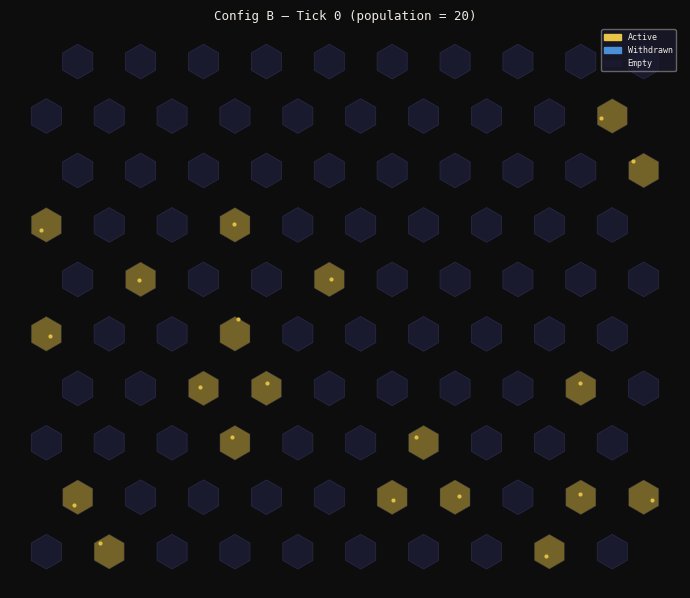


Running Config B — 3000 ticks...
  tick    1 | pop=  21 | withdrawn=   0 | mean_stress=0.000 | phase=expansion | births=1 deaths=0
  tick   51 | pop= 256 | withdrawn=   0 | mean_stress=0.092 | phase=expansion | births=11 deaths=0
  tick  101 | pop= 503 | withdrawn= 115 | mean_stress=0.646 | phase=saturation | births=2 deaths=22
  tick  151 | pop= 585 | withdrawn= 108 | mean_stress=0.533 | phase=saturation | births=6 deaths=9
  tick  201 | pop= 531 | withdrawn= 119 | mean_stress=0.491 | phase=saturation | births=7 deaths=9
  tick  251 | pop= 493 | withdrawn= 123 | mean_stress=0.529 | phase=saturation | births=9 deaths=10
  tick  301 | pop= 500 | withdrawn= 142 | mean_stress=0.545 | phase=saturation | births=7 deaths=5
  tick  351 | pop= 508 | withdrawn= 134 | mean_stress=0.506 | phase=saturation | births=8 deaths=3
  tick  401 | pop= 492 | withdrawn= 149 | mean_stress=0.535 | phase=saturation | births=8 deaths=9
  tick  451 | pop= 521 | withdrawn= 141 | mean_stress=0.513 | phase=satura

In [36]:
# ── Sanity-check: run Config B for 3000 ticks and visualise initial state ──────

sim_demo = Simulation(CONFIG_B, seed=42)

# Draw initial hex grid
fig, ax = plt.subplots(figsize=(7, 7))
draw_grid(sim_demo, ax, title=f"Config B — Tick 0 (population = {len(sim_demo.alive_agents)})")
plt.tight_layout()
plt.show()

print("\nRunning Config B — 3000 ticks...")
df_demo = sim_demo.run(ticks=3000, verbose=True)

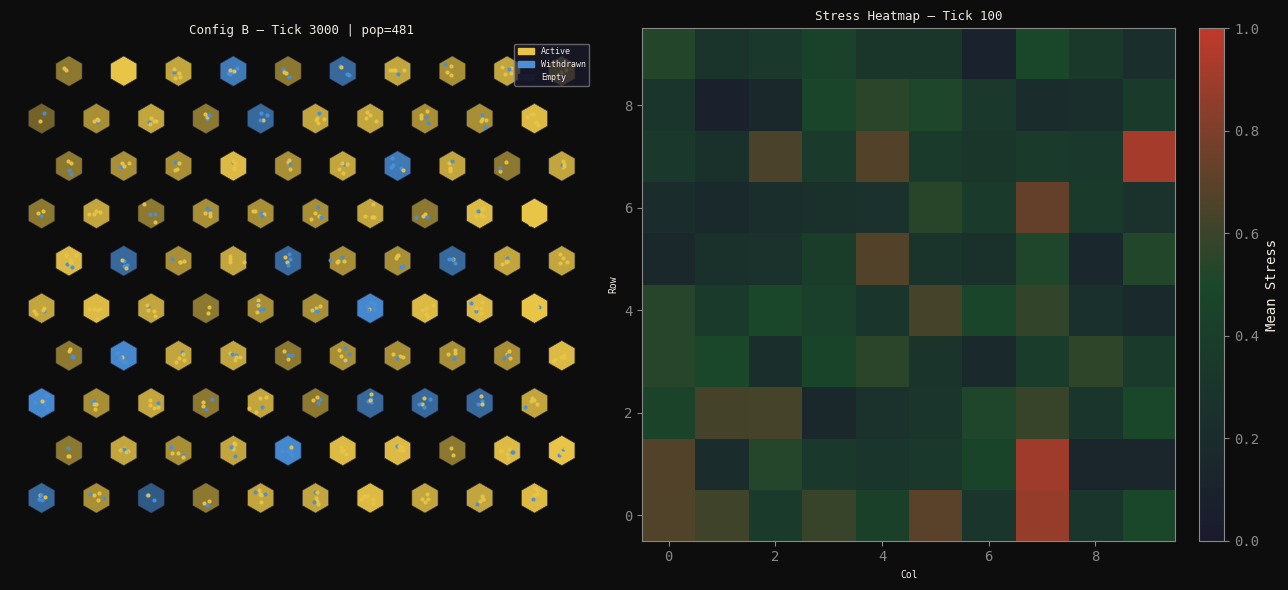

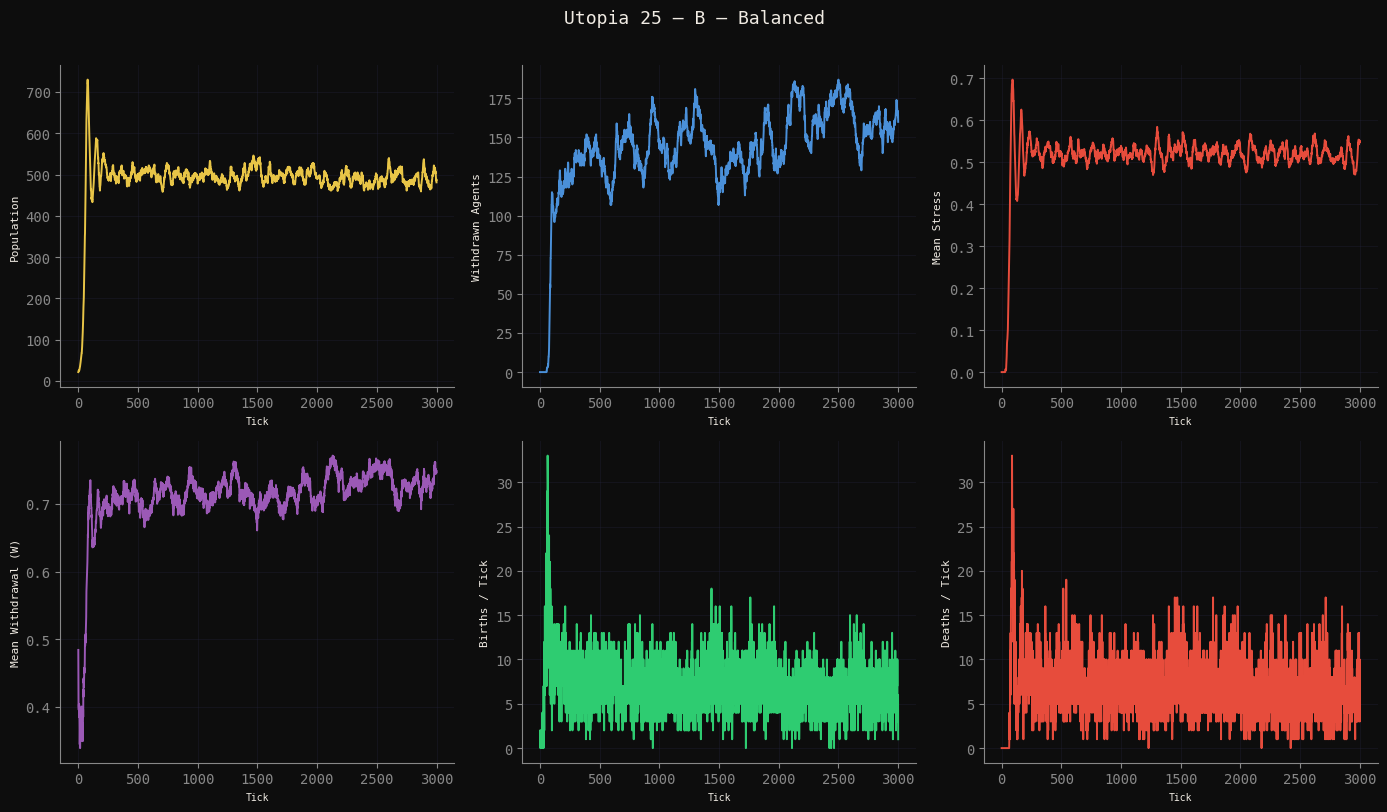

In [37]:
# Grid state at tick 100
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
draw_grid(sim_demo, axes[0],
          title=f"Config B — Tick {sim_demo.tick} | pop={len(sim_demo.alive_agents)}")
plot_stress_heatmap(sim_demo, axes[1], title="Stress Heatmap — Tick 100")
plt.tight_layout()
plt.show()

# Metrics
plot_metrics(df_demo, CONFIG_B.name)

### 8.2  Full four-condition experiment

In [38]:
results: Dict[str, pd.DataFrame] = {}
simulations: Dict[str, Simulation] = {}
summaries = []

for cfg in ALL_CONFIGS:
    print(f"\n{'='*60}")
    print(f"  Running: {cfg.name}")
    print(f"  {cfg.description[:80]}...")
    print(f"{'='*60}")

    sim = Simulation(cfg, seed=42)
    df  = sim.run(ticks=MAX_TICKS, verbose=True)

    results[cfg.name]    = df
    simulations[cfg.name]= sim
    summaries.append(compute_summary(df, cfg.name))

summary_df = pd.DataFrame(summaries)
print("\n" + "="*60)
print("EXPERIMENT COMPLETE — Summary Table")
print("="*60)
print(summary_df.to_string(index=False))


  Running: A — Sparse
  Low initial density (8 founders).  Agents can move freely across the full grid. ...
  tick    1 | pop=   9 | withdrawn=   0 | mean_stress=0.000 | phase=expansion | births=1 deaths=0
  tick   51 | pop=  35 | withdrawn=   0 | mean_stress=0.000 | phase=expansion | births=3 deaths=0
  tick  101 | pop= 475 | withdrawn=   1 | mean_stress=0.216 | phase=expansion | births=21 deaths=0
  tick  151 | pop= 528 | withdrawn= 110 | mean_stress=0.564 | phase=saturation | births=8 deaths=13
  tick  201 | pop= 615 | withdrawn= 132 | mean_stress=0.528 | phase=saturation | births=17 deaths=13
  tick  251 | pop= 575 | withdrawn= 128 | mean_stress=0.523 | phase=saturation | births=11 deaths=17
  tick  301 | pop= 544 | withdrawn= 143 | mean_stress=0.542 | phase=saturation | births=11 deaths=14
  tick  351 | pop= 588 | withdrawn= 137 | mean_stress=0.534 | phase=saturation | births=12 deaths=10
  tick  401 | pop= 538 | withdrawn= 152 | mean_stress=0.486 | phase=saturation | births=11 d

### 8.3  Comparative population curves

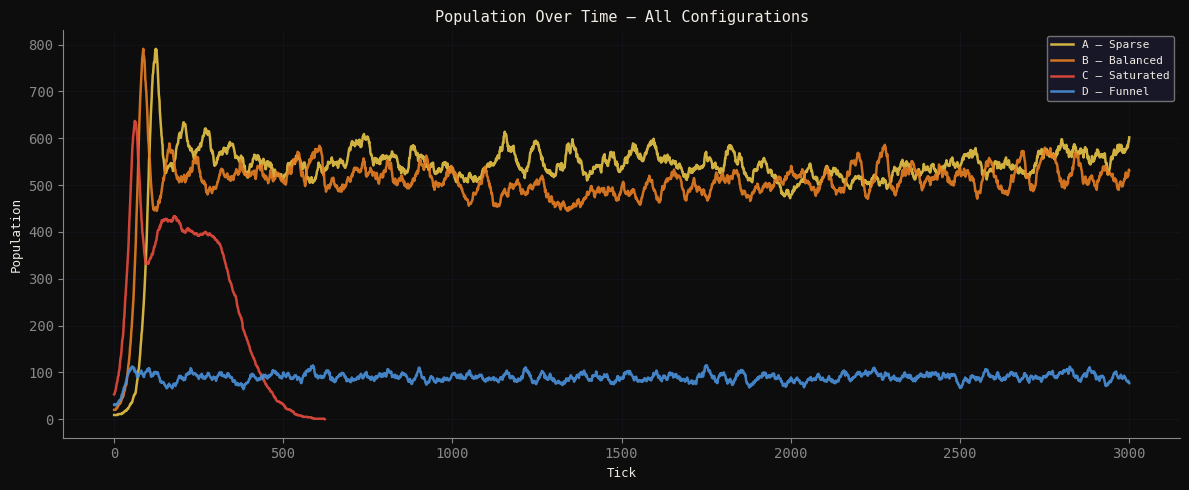

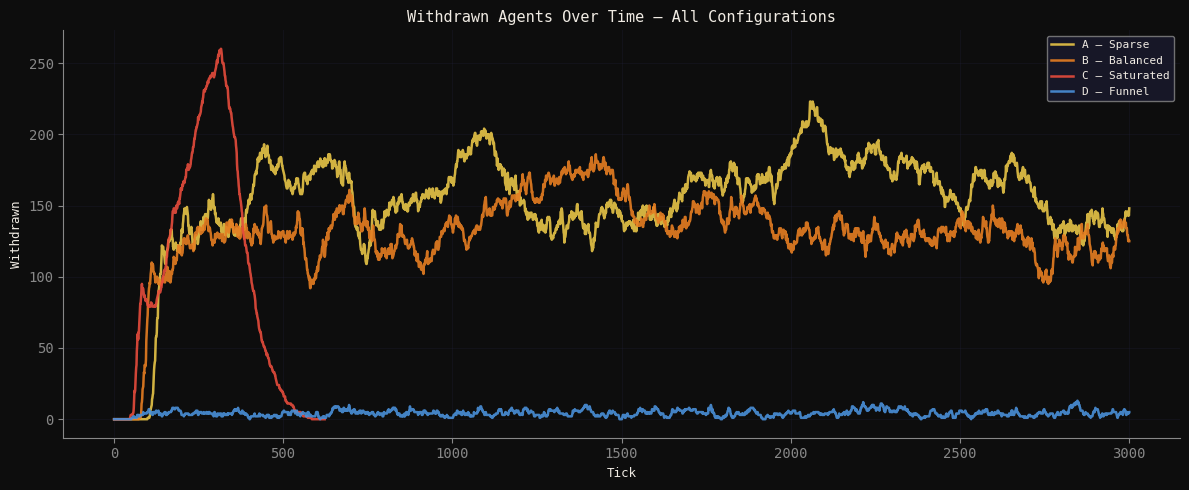

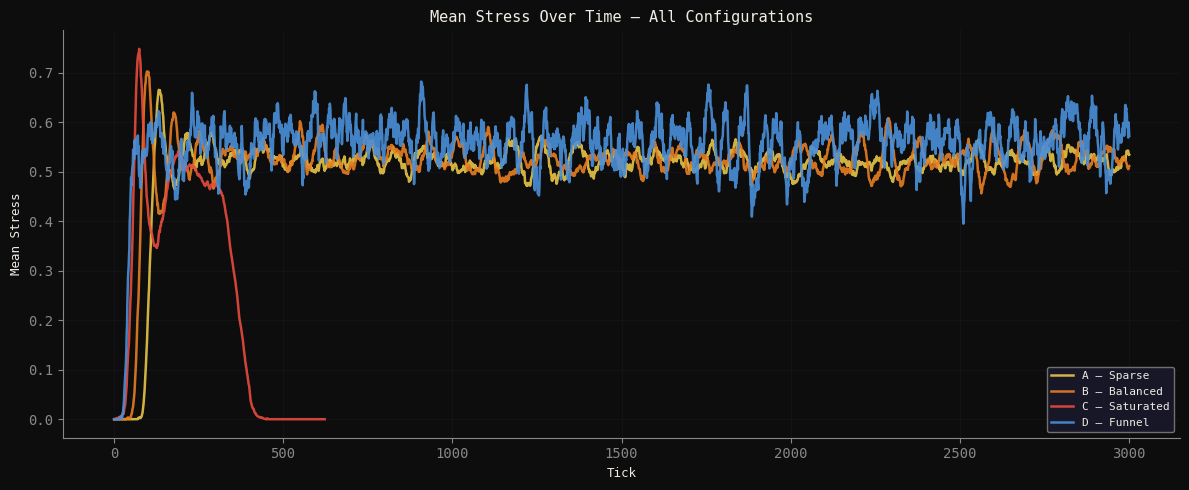

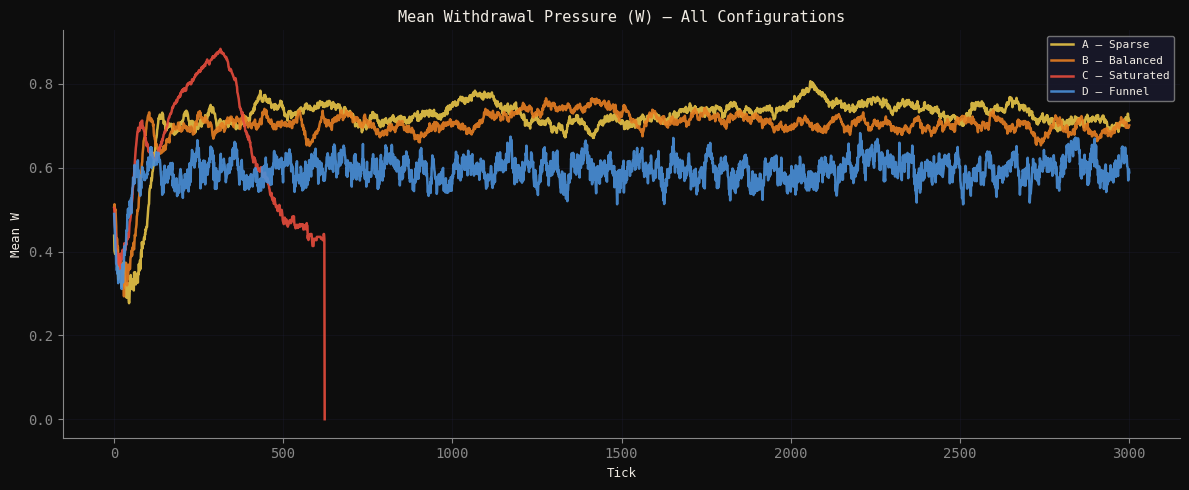

In [39]:
plot_comparative(results, variable="population",
                 title="Population Over Time — All Configurations")
plot_comparative(results, variable="withdrawn",
                 title="Withdrawn Agents Over Time — All Configurations")
plot_comparative(results, variable="mean_stress",
                 title="Mean Stress Over Time — All Configurations")
plot_comparative(results, variable="mean_W",
                 title="Mean Withdrawal Pressure (W) — All Configurations")

### 8.4  End-state hex grids and stress heatmaps

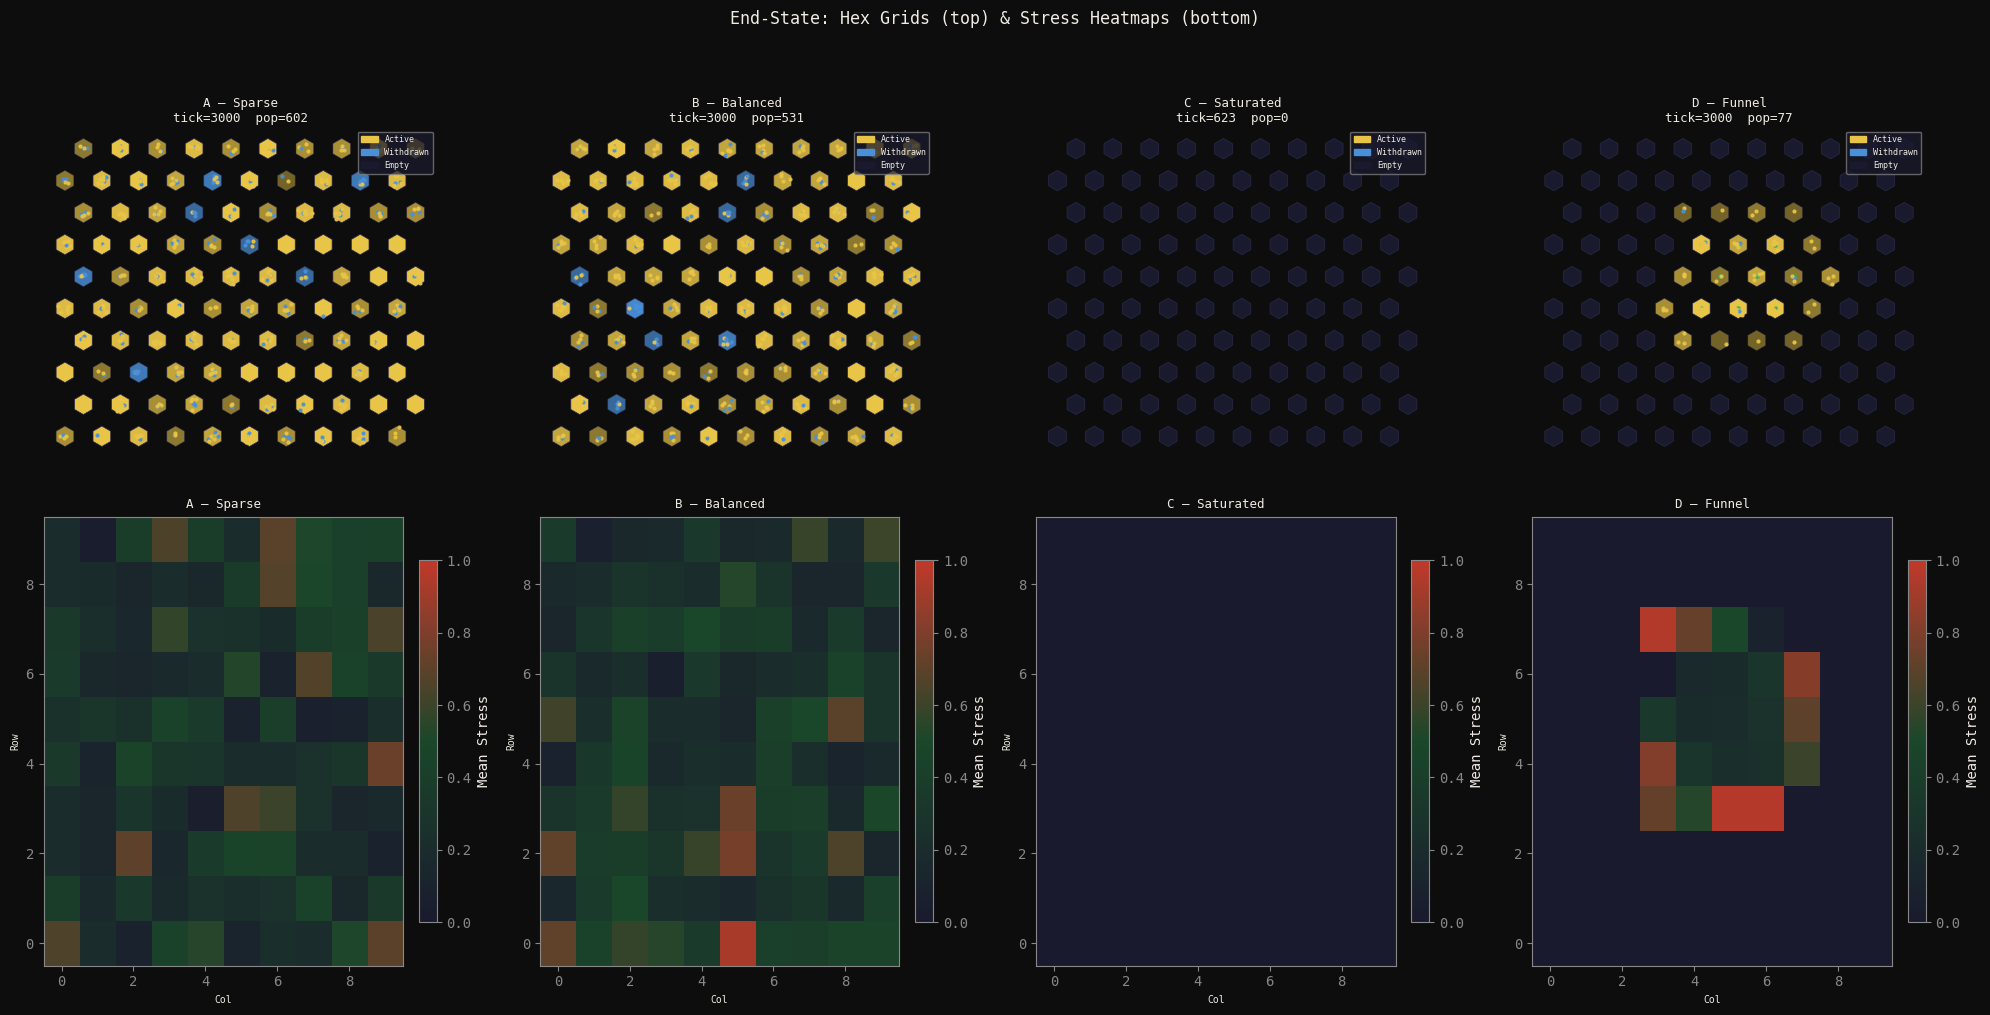

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("End-State: Hex Grids (top) & Stress Heatmaps (bottom)",
             color=PALETTE["text"], fontsize=12, y=1.01)

for col_idx, cfg in enumerate(ALL_CONFIGS):
    sim = simulations[cfg.name]
    n   = len(sim.alive_agents)
    draw_grid(sim, axes[0, col_idx],
              title=f"{cfg.name}\ntick={sim.tick}  pop={n}")
    plot_stress_heatmap(sim, axes[1, col_idx], title=cfg.name)

plt.tight_layout()
plt.show()

### 8.5  Phase portraits and density–withdrawal scatter

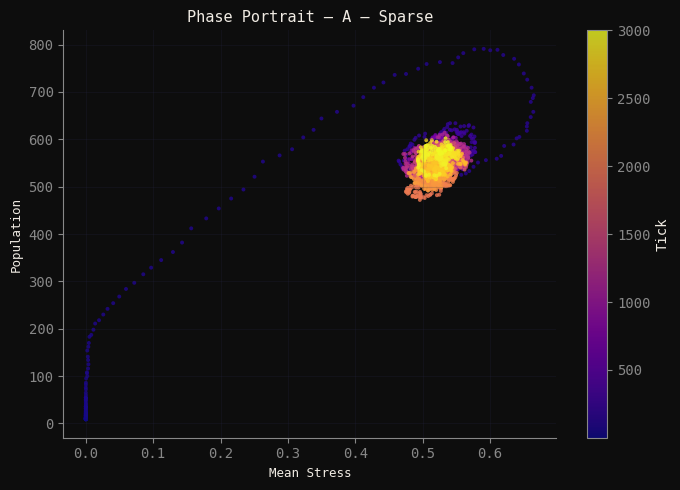

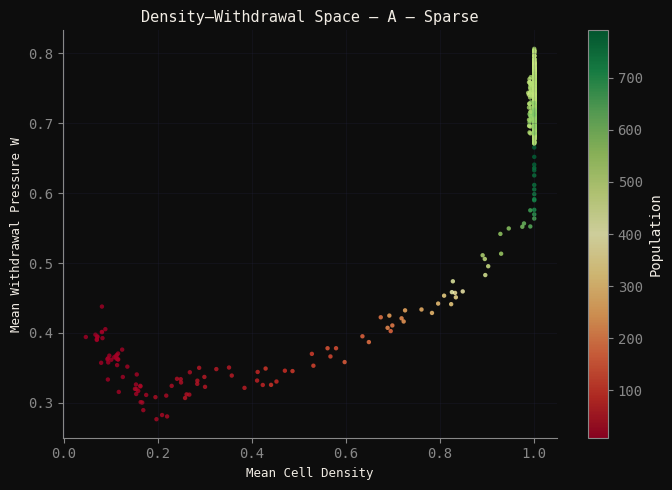

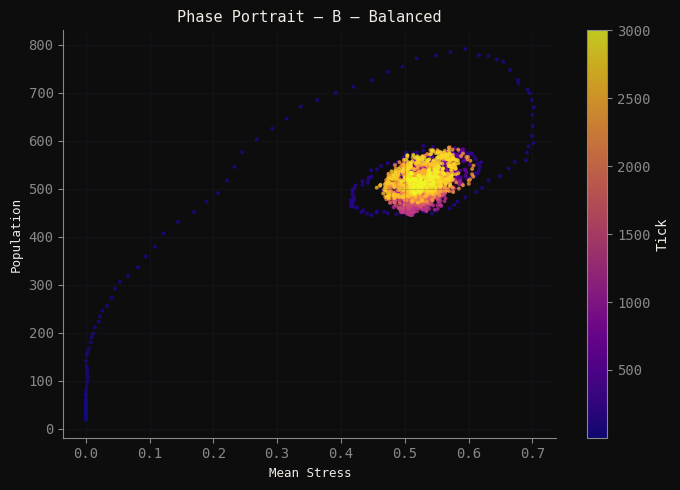

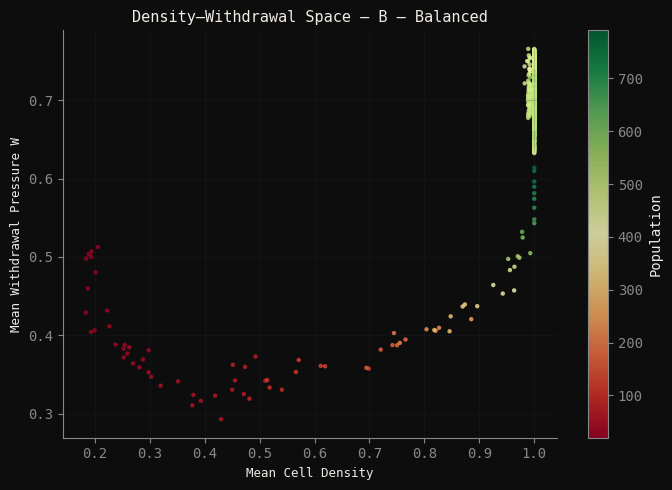

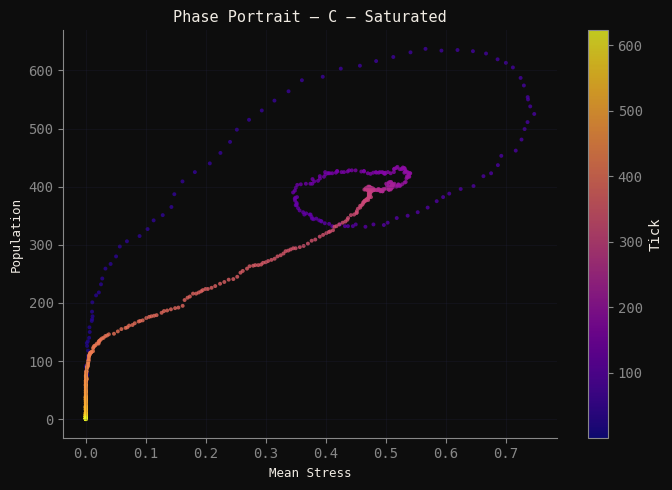

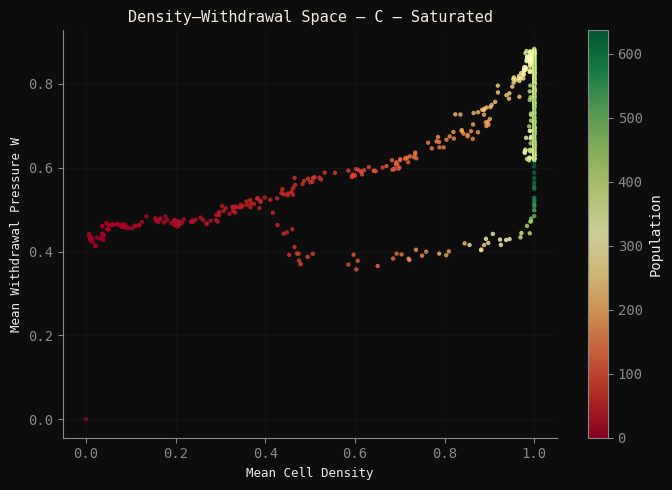

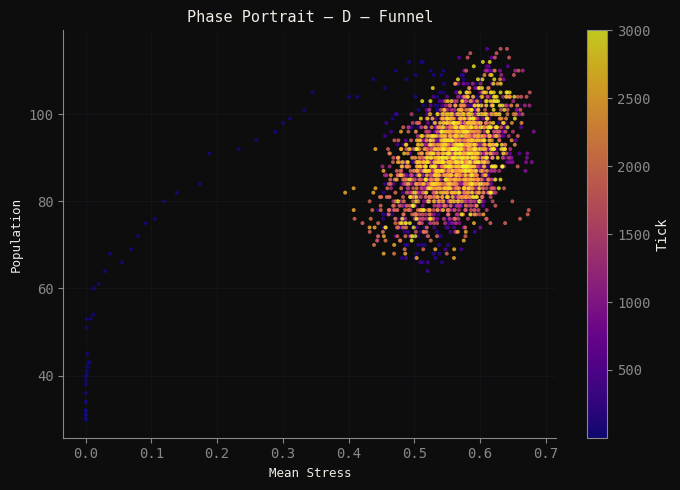

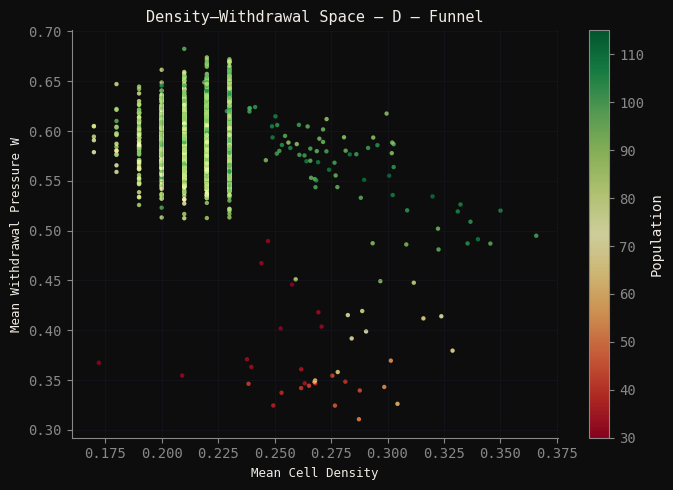

In [41]:
for cfg in ALL_CONFIGS:
    df = results[cfg.name]
    plot_phase_portrait(df, cfg.name)
    plot_withdrawal_vs_density(df, cfg.name)

### 8.6  Summary statistics

In [42]:
# Styled summary table
print("\n── Utopia 25 Experiment Summary ──────────────────────────────────────")
print(summary_df.to_string(index=False))

# Additional: birth–death rates across full runs
print("\n── Net Reproduction (births − deaths) ────────────────────────────────")
for cfg in ALL_CONFIGS:
    df = results[cfg.name]
    net = df["births"].sum() - df["deaths"].sum()
    avg_b = df["births"].mean()
    avg_d = df["deaths"].mean()
    print(f"  {cfg.name:<24} net={net:>5}  avg_births={avg_b:.3f}/tick  avg_deaths={avg_d:.3f}/tick")


── Utopia 25 Experiment Summary ──────────────────────────────────────
       config  peak_pop  peak_tick  final_pop  total_births  total_deaths  max_mean_stress  max_mean_W  max_withdrawn  behavioural_sink_tick
   A — Sparse       791        124        602         25817         25223            0.665       0.806            223                    NaN
 B — Balanced       791         87        531         24814         24303            0.702       0.765            186                    NaN
C — Saturated       637         62          0          1174          1224            0.748       0.883            260                  240.0
   D — Funnel       115        588         77          8736          8689            0.682       0.683             13                    NaN

── Net Reproduction (births − deaths) ────────────────────────────────
  A — Sparse               net=  594  avg_births=8.606/tick  avg_deaths=8.408/tick
  B — Balanced             net=  511  avg_births=8.271/tick  avg_dea

---
## 🔬 Extension: Parameter Sensitivity

Sweep `ALPHA` (density weight in W) across a range and record peak population and collapse tick for Config C (Saturated). This shows how sensitive the behavioural sink onset is to the relative importance of overcrowding vs. direct stress.

Sweeping α (density weight) for Config C...
  α=0.10  peak_pop= 669  final_pop= 453  sink_tick=None
  α=0.20  peak_pop= 669  final_pop= 453  sink_tick=None
  α=0.35  peak_pop= 669  final_pop= 453  sink_tick=None
  α=0.50  peak_pop= 669  final_pop= 453  sink_tick=None
  α=0.65  peak_pop= 669  final_pop= 453  sink_tick=None
  α=0.80  peak_pop= 669  final_pop= 453  sink_tick=None


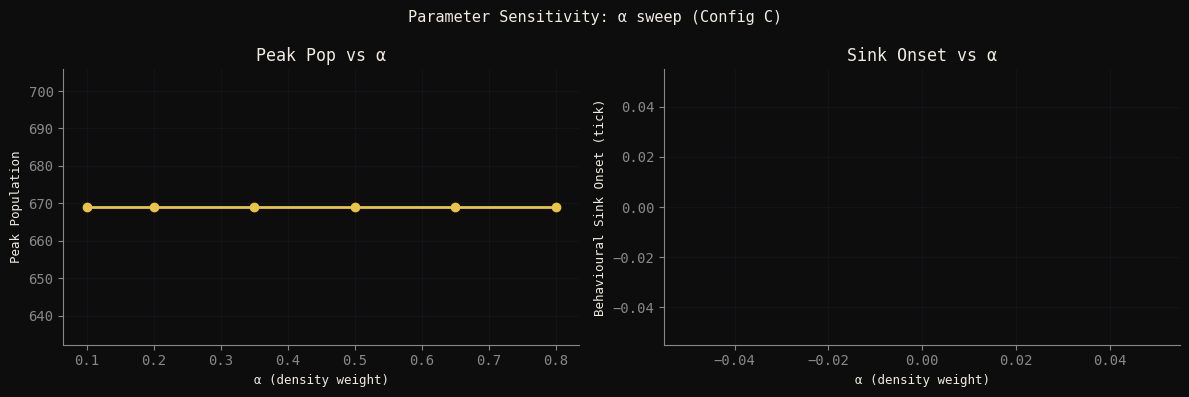

In [47]:
import importlib
import sys

alpha_values = [0.1, 0.2, 0.35, 0.5, 0.65, 0.8]
sweep_results = []

print("Sweeping α (density weight) for Config C...")

for alpha_val in alpha_values:
    # Temporarily override the global
    ALPHA = alpha_val

    sim_s = Simulation(CONFIG_C, seed=123)
    # Monkey-patch: override compute_withdrawal_pressure lambda
    _alpha = alpha_val
    orig_cwp = RatAgent.compute_withdrawal_pressure
    def _patched_cwp(self, density, interaction_norm,
                     _a=_alpha):
        W = (
            _a   * density
            + BETA  * self.stress
            + GAMMA * self.reproductive_frustration
            + DELTA * interaction_norm
        )
        self.withdrawal_pressure = min(W, 1.0)
        return self.withdrawal_pressure
    RatAgent.compute_withdrawal_pressure = _patched_cwp

    df_s = sim_s.run(ticks=200, verbose=False)

    # Restore
    RatAgent.compute_withdrawal_pressure = orig_cwp
    ALPHA = 0.35   # restore global

    s = compute_summary(df_s, f"α={alpha_val}")
    sweep_results.append(s)
    print(f"  α={alpha_val:.2f}  peak_pop={s['peak_pop']:>4}  "
          f"final_pop={s['final_pop']:>4}  "
          f"sink_tick={s['behavioural_sink_tick']}")

sweep_df = pd.DataFrame(sweep_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(alpha_values, sweep_df["peak_pop"], 'o-',
             color=PALETTE["active"], linewidth=2)
axes[0].set_xlabel("α (density weight)", fontsize=9)
axes[0].set_ylabel("Peak Population", fontsize=9)
axes[0].set_title("Peak Pop vs α", color=PALETTE["text"])
axes[0].grid(True, alpha=0.2)

valid = sweep_df.dropna(subset=["behavioural_sink_tick"])
axes[1].scatter(valid["config"].apply(lambda s: float(s.split('=')[1])),
                valid["behavioural_sink_tick"],
                color=PALETTE["withdrawn"], s=80, zorder=3)
axes[1].set_xlabel("α (density weight)", fontsize=9)
axes[1].set_ylabel("Behavioural Sink Onset (tick)", fontsize=9)
axes[1].set_title("Sink Onset vs α", color=PALETTE["text"])
axes[1].grid(True, alpha=0.2)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.suptitle("Parameter Sensitivity: α sweep (Config C)",
             color=PALETTE["text"], fontsize=11)
plt.tight_layout()
plt.show()

---
## Notes & Extensions

### Theoretical grounding

This model formalises three of Calhoun's empirically observed phases:

| Phase | Calhoun label | Model signal |
|---|---|---|
| 1 | *Strive* (exponential growth) | population ↑, W low |
| 2 | *Equilibrium* | population stabilises, W creeps up |
| 3 | *Behavioural Sink* | withdrawn > active, births collapse |
| 4 | *Die-off* | population → 0, stress → max |

### Suggested extensions

- **Dominance hierarchy**: add a `rank` attribute; high-rank males control food cells in Config D.
- **Probers and Beautiful Ones**: distinguish sub-types of withdrawn agents with different recovery probabilities.
- **Multiple runs**: wrap `Simulation.run()` in a loop and compute confidence intervals on peak population and sink onset.
- **Intervention experiment**: at tick 150, remove the top 20 % most-stressed agents. Does the population recover?
- **Continuous-space extension**: replace the hex grid with a Pygame canvas and add velocity/inertia to movement.

### References

- Calhoun, J.B. (1962). *Population density and social pathology*. Scientific American, 206(2), 139–148.
- Calhoun, J.B. (1973). *Death squared: the explosive growth and demise of a mouse population*. Proceedings of the Royal Society of Medicine, 66(1), 80–88.
- Ramsden, E. & Adams, J. (2009). *Escaping the laboratory*. Science in Context, 22(3), 317–357.

---
*Model developed for research and educational purposes. All parameter values are exploratory and do not constitute calibrated empirical estimates.*